# Tutorial for the use of this code / to allow me to remember how it works in a few months


This code was develloped with the goal of being able to use it both as a CLI tool that handles the full automation (takes the atomic structure in input and gives the wannier functions out), or as a python package, to determine automatically projections. It works with WannierBerri and GPAW, so the `dft` and `wannier` modules are basically wrappers of the functionalities for the CLI, which can also be used separately.

Both modes will be demonstrated shortly in this tutorial.

## CLI


The CLI can be invoked in a terminal easily using the following command:

```bash
uv run pawan < input cif path > --options

```

A list of all the options is obtained with ```--h ```. The most useful ones are the following:
- ```--auto-nk-grid```: use a k-grid automatically determined from the spacegroup rather than the default,
- ```--output-dir```: directory where the output files are dumped (.npz files from wannierisation),
- ```--input-dir```: directory where existing dft (nscf and bands) files can be read. Will skip the DFT and use those,
- ```--skip-scf```, ```--skip-nscf```, ```--skip-wannier```: skip a given part of the calculation for a re-run (the files must exist already).
- ```--K```: empirical parameter between 1 and 2 that sets the size of the outer window relatively to the number of Wannier functions.
- ```--pdos```: use another simpler method for determination of the projections instead of the ```EBRsearcher```, that uses a pDOS trheshold (faster but fails for some materials).

If your installation of GPAW allows it, you may want to compute the dft on multiple cores, using MPI. This can be done like this:

```bash
mpirun -np < number of cores > uv run pawan < input cif path > --options

```

### Outputs


The following files are created within the ```out-dir``` directory:

- DFT files:
    - ```seed-scf.gpw``` and ```seed-scf.txt```: output and log from the scf computation,
    - ```seed-nscf-irred.gpw``` and ```seed-nscf-irred.txt```: output and log from the nscf computation,
    - ```seed-bands.gpw``` and ```seed-bands.txt```: output and log from the band structure computation.
- Projection determination files:
    - ```ebr_selection.log```: contains the projection alphabet that was used and all considered projection sets out of the alphabet,
    - ```orbitals_and_windows.txt```: contains the final selected projection set and the corresponding energy windows.
- Wannierisation files:
    - ```seed-wannier-data.amn.npz```: AMN matrix from the selected projection set.
    - ```seed-wannier-data.bkvec.npz```: k-space basis vectors
    - ```seed-wannier-data.chk.npz```: wannierization data, can be reloaded to start a new computation from the result,
    - ```seed-wannier-data.eig.npz```: DFT band eigenvalues
    - ```seed-wannier-data.mmn.npz```: overlap between Bloch states across k-points
    - ```seed-wannier-data.sawf.npz```: symmetrizer for SAWF, can  be reloaded for other purposes if needed,
    - ```seed-wannier-data.unk.npz```: bloch wavefunction on a real-space grid.
- Quality assesment
    - ```seed-wannierized_bands.png```: match between the dft bands and the interpolated bands for visual inspection,
    - ```seed-wannier_spreads.txt```: final spreads of all the wannier functions, and quadratic band distance (mean and maximal).
    





    

The CLI behavior can be replicated in Python using the ```auto_workflow``` utility and setting parameters manually:

Estimated number of bands based on valence electrons: 40. Will be capped between 18 and 200.
Running SCF calculation for Si2 in directory test_tutorial
Using k-mesh: 6x6x6
Automatically determined G-grid: [20 20 20]
The space group is non-symmorphic. Adjusting G-grid to be compatible with the translations.
Adjusted G-grid to satisfy both ecut and symmetry: (20, 20, 20)
Running NSCF calculation for Si2 in directory test_tutorial
DFT bands already computed for Si2. Skipping.
DFT calculations completed for Si2. Proceeding with Wannierization.
Building bandstructure...
building symmetrizer...
mpgrid = [6 6 6], 16
['-1.0*x+1.0*y+1.0*z-0.5,1.0*x-1.0*y+1.0*z-0.5,1.0*x+1.0*y-1.0*z+0.5', '-0.375000000000000,-2.0*y-0.125,2.0*y+0.375', '1.0*z-0.5,1.0*z-0.5,2.0*x-1.0*z+0.5', '-1.0*x,1.0*x-0.5,1.0*x+0.5', '1.0*x-0.5,1.0*x-0.5,1.0*x+0.5', '0.125000000000000,0.125000000000000,1.12500000000000', '-0.375000000000000,-0.375000000000000,0.625000000000000', '0,0,1.00000000000000', '-0.250000000000000,-0.2

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file mmn cntains 16 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file eig cntains 16 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file chk cntains 66 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Use

Setting AMN with kwargs={'kptirr': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]), 'NK': 216, 'selected_kpoints': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])}
finding num points from 1 projections
finding num points from 1 projections
Creating amn. Using projections_set 
ProjectionsSet with 8 Wannier functions and 0 free variables
Projection 0.75, 0.75, 0.75:['WP_-1/4,-1/4,3/4__hyb'] with 8 Wannier functions (8 per spin x1 spins) 
 on 2 points (4 per site)
AMN file created with NK=216
saving to test_tutorial/Si2/Si2_wannier_data.mmn.npz : 
saving to test_tutorial/Si2/Si2_wannier_data.eig.npz : 
saving to test_tutorial/Si2/Si2_wannier_data.chk.npz : 
saving to test_tutorial/Si2/Si2_wannier_data.sawf.npz : 
saving to test_tutorial/Si2/Si2_wannier_data.bkvec.npz : 
saving to test_tutorial/Si2/Si2_wannier_data.amn.npz : 


/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-31 18:38:34,418	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Using the Wannier centers from the chk file as initial guess
Starting Wannier centers (in reduced coordinates) = 
 [[0.75 0.75 0.75]
 [0.75 0.75 0.75]
 [0.75 0.75 0.75]
 [0.75 0.75 0.75]
 [0.5  0.5  0.5 ]
 [0.5  0.5  0.5 ]
 [0.5  0.5  0.5 ]
 [0.5  0.5  0.5 ]]


...

####################################################################################################
starting WFs
----------------------------------------------------------------------------------------------------
wannier centers and spreads
----------------------------------------------------------------------------------------------------
  3.811571311572    3.811571311572    3.811571311572   |   111.986309572222
  4.333428688428    4.333428688428    3.811571311572   |   111.986309572222
  4.333428688428    3.811571311572    4.333428688428   |   111.986309572222
  3.811571311572    4.333428688428    4.333428688428   |   111.986309572222
  2.975928688428    2.454071311572    2.454071311572   |   111.986309572222
  2.454071311572    2.975928688428    2.454071311572   |   111.986309572222
  2.975928688428    2.975928688428    2.975928688428   |   111.986309572222
  2.454071311572    2.454071311572    2.975928688428   |   111.986309572222
------------------------------------------------

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file amn cntains 16 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file mmn cntains 16 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file eig cntains 16 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Use

setting Rvec
setting AA..
setting AA - OK
Real-space lattice:
 [[0.    2.715 2.715]
 [2.715 0.    2.715]
 [2.715 2.715 0.   ]]
Number of wannier functions: 8
Number of R points: 339
Recommended size of FFT grid [6 6 6]
num_blocks_left = 1, num_blocks_right = 1
number o R-vectors before symmetrization: 339
number o R-vectors after symmetrization: 663
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x1388efd40>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x13a7aa990> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


setting file symmetrizer from npz test_tutorial/Si2/Si2_wannier_data.sawf.npz as <wannierberri.symmetry.sawf.SymmetrizerSAWF object at 0x13af06630>
Trying to read file bkvec from npz test_tutorial/Si2/Si2_wannier_data.bkvec.npz
setting file bkvec from npz test_tutorial/Si2/Si2_wannier_data.bkvec.npz as <wannierberri.w90files.bkvectors.BKVectors object at 0x13a8c4b90>
Setting AMN with kwargs={'kptirr': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]), 'NK': 216, 'selected_kpoints': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])}
finding num points from 1 projections
finding num points from 1 projections
Creating amn. Using projections_set 
ProjectionsSet with 8 Wannier functions and 0 free variables
Projection 0.75, 0.75, 0.75:['WP_-1/4,-1/4,3/4__hyb'] with 8 Wannier functions (8 per spin x1 spins) 
 on 2 points (4 per site)
AMN file created with NK=216
saving to test_tutorial/Si2/Si2_wannier_data.mmn.npz : 
saving to test_tutorial/Si2/Si2

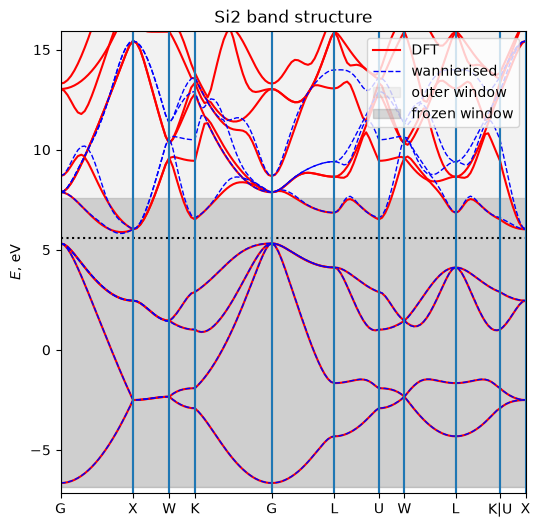

In [1]:
from pawan.utils import standardize_cell
from pawan.main import auto_workflow
from ase.io import read
from pathlib import Path as Path_
seed = "Si2"
output_dir = "test_tutorial"
input_dir = "test_tutorial"
(Path_(output_dir) / Path_(f"{seed}")).mkdir(parents=True, exist_ok=True)

atoms = standardize_cell(read(f"test/{seed}/{seed}.cif"))
auto_workflow(atoms, seed, in_dir=input_dir, out_dir=output_dir,nk=6)

The small imperfections observed here are corrected with a denser k-grid.

One can see that the DFT computation is very slow, because it runs here on a single core. To make it multicore, use ```mpirun``` with the CLI or within ```os.subprocess```.

## Package use

The main interest of this mode is to use the code simply to determine projections, and to then perform the wannierization manually from the result, possibly in another code using ```WannierBerri```'s rich interfaces. For completeness, wannierisation is also demonstrated here  

We will here consider the simple example of bulk sillicon. We will re-use the DFT done above. If we wanted to perform it again manually, it can be done either step-by-step with ```pawan.dft.scf```, ```pawan.dft.ncf```, ```pawan.dft.dft_bands```, either all at once with ```pawan.dft.full_dft_run```.

### imports and i/o parameters:

In [2]:
from gpaw import GPAW
from gpaw.mpi import serial_comm # in case it is run within MPI, this will ensure that the wannierisation code runs in serial mode (as WannierBerri does not support MPI, but uses Ray)

from pawan.wannier import wannierize, interpolate_bands
from pawan.ebr_method import EBR_method
from pawan.main import plot_bands

seed = "Si2"
seed = "Si2"
output_dir = "test_tutorial_manual"
input_dir = "test_tutorial"
(Path_(output_dir) / Path_(f"{seed}")).mkdir(parents=True, exist_ok=True)


### find projection set

In [5]:
#notice that here, as we do it manually, we should set the same ecut that was used in the DFT, here ok as default
K=1.2 #how does the outside window scales compared to the number of wannier functions : number of states in it is K*number of wannier functions
validate = False  # whether to validate the projections by running a wannierization and checking the spread and band interpolation error, here un-necessary as it is an easy case. In doubt, turn it on, but it will take longer to run.
proj_set, frozen_win, outer_win = EBR_method(in_dir=input_dir, out_dir=output_dir, seed=seed,K=K,ecut=500, comm=serial_comm,validate=validate, eta_ok=20.0, spread_ok=10.0)


Building bandstructure...
building symmetrizer...
mpgrid = [6 6 6], 16
['-1.0*x+1.0*y+1.0*z-0.5,1.0*x-1.0*y+1.0*z-0.5,1.0*x+1.0*y-1.0*z+0.5', '-0.375000000000000,-2.0*y-0.125,2.0*y+0.375', '1.0*z-0.5,1.0*z-0.5,2.0*x-1.0*z+0.5', '-1.0*x,1.0*x-0.5,1.0*x+0.5', '1.0*x-0.5,1.0*x-0.5,1.0*x+0.5', '0.125000000000000,0.125000000000000,1.12500000000000', '-0.375000000000000,-0.375000000000000,0.625000000000000', '0,0,1.00000000000000', '-0.250000000000000,-0.250000000000000,0.750000000000000']
Selected positions for projections:
-1/4,-1/4,3/4
alphabet = 'isotypic+hyb'
WP_-1/4,-1/4,3/4_ @ [0.75 0.75 0.75]  |G_q|=24  spd -> bond-pointing hybrid: ['WP_-1/4,-1/4,3/4__hyb', 'WP_-1/4,-1/4,3/4__rest0', 'WP_-1/4,-1/4,3/4__rest1']   [minimal-shell hybrid on sp, d left as complement]
      WP_-1/4,-1/4,3/4__hyb-1  = +0.500|s> -0.500|pz> -0.500|px> -0.500|py>
      WP_-1/4,-1/4,3/4__hyb-2  = +0.500|s> -0.500|pz> +0.500|px> +0.500|py>
      WP_-1/4,-1/4,3/4__hyb-3  = +0.500|s> +0.500|pz> +0.500|px> -0.500|p

Here we can see that the selected projection set contains 8 Wannier functions and it is labelled as hybrids. An inspection of ```orbitals_and_windows.txt``` shows that it corresponds to the textbook $sp^3$. We can then proceed with the wannierisation:

Computing wannierization files for Si2...
finding num points from 1 projections
finding num points from 1 projections
got irreducible=True, mp_grid=None, seedname=wannier, files=['amn', 'mmn', 'eig', 'symmetrizer'],  projections=ProjectionsSet with 8 Wannier functions and 0 free variables
Projection 0.75, 0.75, 0.75:['WP_-1/4,-1/4,3/4__hyb'] with 8 Wannier functions (8 per spin x1 spins) 
 on 2 points (4 per site), unk_grid=(np.int64(20), np.int64(20), np.int64(20)), normalize=True
self.irreducible=True
mpgrid = [6 6 6], 16
Shells found with weights [3.36087559] and tolerance 3.8471957400026765e-16
Creating amn. Using projections_set 
ProjectionsSet with 8 Wannier functions and 0 free variables
Projection 0.75, 0.75, 0.75:['WP_-1/4,-1/4,3/4__hyb'] with 8 Wannier functions (8 per spin x1 spins) 
 on 2 points (4 per site)
NK= 216, selected_kpoints = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15], kptirr = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Using PAW kpoints for MMN: [ar

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/parallel.py:121: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")


####################################################################################################
Iteration 0 (from wannierizer)
----------------------------------------------------------------------------------------------------
wannier centers and spreads
----------------------------------------------------------------------------------------------------
  3.830640361785    3.830640361785    3.830640361785   |     3.457348091058
  4.314359638215    4.314359638215    3.830640361785   |     3.457348091058
  4.314359638215    3.830640361785    4.314359638215   |     3.457348091058
  3.830640361785    4.314359638215    4.314359638215   |     3.457348091058
  2.956859638215    2.473140361785    2.473140361785   |     3.457348091058
  2.473140361785    2.956859638215    2.473140361785   |     3.457348091058
  2.956859638215    2.956859638215    2.956859638215   |     3.457348091058
  2.473140361785    2.473140361785    2.956859638215   |     3.457348091058
------------------------------

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file amn cntains 16 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file mmn cntains 16 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file eig cntains 16 k-points less than NK (216) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Use

setting Rvec
setting AA..
setting AA - OK
Real-space lattice:
 [[0.    2.715 2.715]
 [2.715 0.    2.715]
 [2.715 2.715 0.   ]]
Number of wannier functions: 8
Number of R points: 339
Recommended size of FFT grid [6 6 6]
num_blocks_left = 1, num_blocks_right = 1
number o R-vectors before symmetrization: 339
number o R-vectors after symmetrization: 663
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x13bc62360>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x13f2e5f40> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


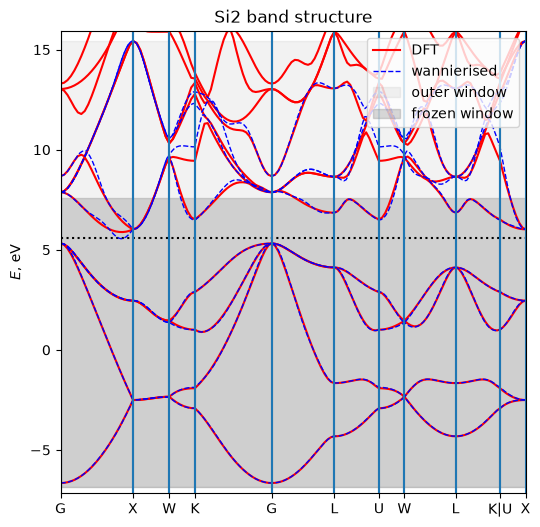

In [6]:
unitary_params = dict(
                    error_threshold=0.1,
                    warning_threshold=0.01,
                    nbands_upper_skip=2,# this should be corresponding to the number of unconverged bands in the DFT (or be bigger).
                )

wannierize(
    proj_set=proj_set,
    outer_win=outer_win,
    frozen_win=frozen_win,
    seed=seed,
    out_dir=output_dir,
    in_dir=input_dir,
    unitary_params=unitary_params,
)

bands_wannier, wb_path = interpolate_bands(seed=seed, out_dir=output_dir, in_dir=input_dir)

plot_bands(bands_wannier, wb_path, outer_win, frozen_win, seed=seed, out_dir=output_dir, in_dir=input_dir)

The same result is obtained than with the CLI. It is altough less convenient as some parameters must be set manually instead of being passed through all the workflow, and it thus recommanded to use the CLI for the whole workflow.

Inspecting the ```Si2-wannier_spreads.txt``` files, it appears that the spreads are small ($~3$), while the matching to the band is quite bad. This can be solved by increasing the number of k-points, by using ```--auto-nk``` in the DFT, or manually setting a value that respects the symmetries: ```nk=12```. 

## More complex example: gallium nitride

Here is demonstrated a more complex case that requires validation between the symmetry-adapted outputs of the ```EBRsearcher```, using the CLI and MPI (Here with subprocess for the demonstration, usually would be done directly in a terminal).

In [8]:
import subprocess

subprocess.run([
    "mpirun",
    "-np", "6", # adjust the number of processes as a function of your hardware
    "uv", "run", "pawan",
    "test/Ga2N2/Ga2N2.cif",
    "--auto-nk-grid",
    "--output-dir", "test_tutorial",
    "--skip-scf",
    "--skip-nscf"

], check=True)

Estimated number of bands based on valence electrons: 80. Will be capped between 18 and 200.
Special points in the BZ: {'G': array([0., 0., 0.]), 'A': array([0. , 0. , 0.5]), 'H': array([0.33333333, 0.33333333, 0.5       ]), 'K': array([0.33333333, 0.33333333, 0.        ]), 'L': array([0.5, 0. , 0.5]), 'M': array([0.5, 0. , 0. ])}
Special points in the BZ: {'G': array([0., 0., 0.]), 'A': array([0. , 0. , 0.5]), 'H': array([0.33333333, 0.33333333, 0.5       ]), 'K': array([0.33333333, 0.33333333, 0.        ]), 'L': array([0.5, 0. , 0.5]), 'M': array([0.5, 0. , 0. ])}
Special points in the BZ: {'G': array([0., 0., 0.]), 'A': array([0. , 0. , 0.5]), 'H': array([0.33333333, 0.33333333, 0.5       ]), 'K': array([0.33333333, 0.33333333, 0.        ]), 'L': array([0.5, 0. , 0.5]), 'M': array([0.5, 0. , 0. ])}
Special points in the BZ: {'G': array([0., 0., 0.]), 'A': array([0. , 0. , 0.5]), 'H': array([0.33333333, 0.33333333, 0.5       ]), 'K': array([0.33333333, 0.33333333, 0.        ]), 'L': 

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file mmn cntains 57 k-points less than NK (576) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file eig cntains 57 k-points less than NK (576) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file chk cntains 148 k-points less than NK (576) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Us

Setting AMN with kwargs={'kptirr': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56]), 'NK': 576, 'selected_kpoints': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56])}
finding num points from 1 projections
finding num points from 1 projections
Creating amn. Using projections_set 
ProjectionsSet with 8 Wannier functions and 0 free variables
Projection 0.6666666666666667, 0.3333333333333333, 0.12407110408213018:['WP_0.6666666666666667,0.3333333333333333,0.12407110408213018__hyb'] with 8 Wannier functions (8 per spin x1 spins) 
 on 2 points (4 per site)
AMN file created with NK=576


/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/parallel.py:121: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")


####################################################################################################
starting WFs
----------------------------------------------------------------------------------------------------
wannier centers and spreads
----------------------------------------------------------------------------------------------------
  1.595000000000    0.960580481966    0.701939965964   |     9.574960212032
  1.629387099762    0.901020278053    0.701939965964   |     9.574960212032
  1.595000000000    0.920873679357    0.643443305405   |     9.123286567538
  1.560612900238    0.901020278053    0.701939965964   |     9.574960212032
 -0.034387099762    1.861600760019    3.296939965964   |     9.574960212032
  0.034387099762    1.861600760019    3.296939965964   |     9.574960212032
 -0.000000000000    1.841747358715    3.238443305405   |     9.123286567538
  0.000000000000    1.802040556106    3.296939965964   |     9.574960212032
------------------------------------------------

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file amn cntains 57 k-points less than NK (576) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file mmn cntains 57 k-points less than NK (576) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/w90files/wandata.py:409: UserWarning: file eig cntains 57 k-points less than NK (576) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/Use

setting AA..
setting AA - OK
Real-space lattice:
 [[ 3.19        0.          0.        ]
 [-1.595       2.76262104  0.        ]
 [ 0.          0.          5.19      ]]
Number of wannier functions: 8
Number of R points: 849
Recommended size of FFT grid [12 12  4]
num_blocks_left = 1, num_blocks_right = 1
number o R-vectors before symmetrization: 849
number o R-vectors after symmetrization: 1549
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x12bec54c0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x129e352e0> : calculator not described

--------------------------------------------------

############################################################
Calculation along a 

/Users/julfa/Documents/EPFL/SummerInTheLab/automation/pawan/.venv/lib/python3.12/site-packages/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


setting file mmn from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.mmn.npz as <wannierberri.w90files.mmn.MMN object at 0x12ccfff80>
Trying to read file eig from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.eig.npz
setting file eig from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.eig.npz as <wannierberri.w90files.eig.EIG object at 0x12d3b9a90>
Trying to read file chk from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.chk.npz
setting file chk from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.chk.npz as <wannierberri.w90files.chk.CheckPoint object at 0x12a9c06b0>
Trying to read file symmetrizer from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.symmetrizer.npz
setting file symmetrizer from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.sawf.npz as <wannierberri.symmetry.sawf.SymmetrizerSAWF object at 0x129b70d40>
Trying to read file bkvec from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.bkvec.npz
setting file bkvec from npz test_tutorial/Ga2N2/Ga2N2_wannier_data.bkvec.npz as <wannierberri.w90files.bkvector

CompletedProcess(args=['mpirun', '-np', '6', 'uv', 'run', 'pawan', 'test/Ga2N2/Ga2N2.cif', '--auto-nk-grid', '--output-dir', 'test_tutorial', '--skip-scf', '--skip-nscf'], returncode=0)

## What to do if the result is bad

If the obtained wannierization is bad, i.e. large spreads or/and bad band interpolation (typically spreads > $5\AA^2$ or band distance > $20\text{meV}$), some parameters can be tuned to obtain a better result:

- Try changing the value of $K$, that controls size of the outer window. Increasing it leads to a bigger window and hence more freedom for the disentenglement but also for the EBRsearcher, leading to more combinations and potentially more computational effort. The default is $1.2$, and it can be increased up to $1.5 - 1.7$ usually.
- Try to change the alphabet of the EBRsearcher (if you are not using ```--pdos```), setting it with ```--alphabet``` (possible alphabets are ```shells```, ```shells+hyb```, ```isotypic```, ```isotypic+hyb```). Typically, the isotypic alphabets give more granularity and hence more combinations, leading to also a greater computational effort. Alphabets without hybrids are to be avoided, unless for large materials where the size of the alphabet begins to be a problem.
- Try to increase the number of wannierized projections set in the validation step using ```--validate-n-max``` (default : 5), or increase the maximal number of wannier functions produced in a projection set with ```--EBR-margin``` (default:2, giving 2*number of bands within the frozen window, decreasing can reduce the time of computation for large materials)
- If this fails, you can manually inspect the output of the EBRsearcher ```ebr_selection.log```, to see if a chemistically obvious solution is missed by the validation step.

## Utilities that can be reused

Some utilities that are used here can be re-used in other DFT / wannierisation workflows.

### Automatic symmetry adapted k-grid determination
This utility determines a k-grid starting from a given typical lenght, and then enforcing:
- compatibility with the space group,
- that it contains the high symmetry points (the fractional ones).

In [9]:
from pawan.utils import adaptative_high_sym_k_grid

from ase.build import bulk
atoms = bulk('Si', 'diamond', a=5.43)
k_grid = adaptative_high_sym_k_grid(atoms, nk_length=20, multiplier=1, kill_axis=None, max_denominator=8, tol=1e-5)
print (f"Recommended k-grid for {atoms.get_chemical_formula()} is {k_grid}")


Special points in the BZ: {'G': array([0., 0., 0.]), 'K': array([0.375, 0.375, 0.75 ]), 'L': array([0.5, 0.5, 0.5]), 'U': array([0.625, 0.25 , 0.625]), 'W': array([0.5 , 0.25, 0.75]), 'X': array([0.5, 0. , 0.5])}
Initially determined k-grid: (np.int64(6), np.int64(6), np.int64(6))
Recommended k-grid for Si2 is (8, 8, 8)


### Enforcing the real space g grid to be compatible with non-symmorphic space groups

For space groups with fractional translations, the real space grid must be compatible with the fractional translation. This one is specific to ```GPAW+WannierBerri```, and it allows to avoid a crash.

In [10]:
from pawan.utils import adaptative_g_grid
from gpaw import GPAW

calc = GPAW('test_tutorial/Si2/Si2-scf.gpw', txt=None)
g_grid = adaptative_g_grid(calc,atoms)

Automatically determined G-grid: [20 20 20]
The space group is non-symmorphic. Adjusting G-grid to be compatible with the translations.
Adjusted G-grid to satisfy both ecut and symmetry: (20, 20, 20)


Here the default one determined by ```GPAW``` is already compatible with the 1/2 translation, so it is unchanged.

### Symmetrization of orbitals at an atomic site

The ```pawan.symmetry``` module can be used to compute hybrids on an atomic site, based on the site-symmetry group and given orbitals. In, cases where no exact hybridization exists, a top-down approach is used to find hybrids that use as much orbitals as possible. It defaults to isotypic (irrep-grouped) orbitals if a failure occurs.

First the classic $sp^3$ example :

In [11]:
from pawan.symmetry import build_at, build # build_at works only on a provided atomic site of the atomic structure, build does all of them at once.
from pawan.utils import standardize_cell
from ase import Atoms
import numpy as np
from gpaw import GPAW
from ase.io import read

atoms = standardize_cell(read("test/Si2/Si2.cif"))
pset,res = build_at(atoms=atoms, position=atoms.get_scaled_positions()[0],shells="sp", verbose=True, fallback="minimal_shell",label="Si")
pset,res = build_at(atoms=atoms, position=atoms.get_scaled_positions()[1],shells="sp", verbose=True, fallback="minimal_shell",label="Si")
print(res)



Si @ [0.5 0.5 0.5]  |G_q|=24  sp -> bond-pointing hybrid: ['Si_hyb']
      Si_hyb-1                 = +0.500|s> -0.500|pz> +0.500|px> -0.500|py>
      Si_hyb-2                 = +0.500|s> -0.500|pz> -0.500|px> +0.500|py>
      Si_hyb-3                 = +0.500|s> +0.500|pz> -0.500|px> -0.500|py>
      Si_hyb-4                 = +0.500|s> +0.500|pz> +0.500|px> +0.500|py>
Si @ [0.75 0.75 0.75]  |G_q|=24  sp -> bond-pointing hybrid: ['Si_hyb']
      Si_hyb-1                 = +0.500|s> -0.500|pz> -0.500|px> -0.500|py>
      Si_hyb-2                 = +0.500|s> -0.500|pz> +0.500|px> +0.500|py>
      Si_hyb-3                 = +0.500|s> +0.500|pz> +0.500|px> -0.500|py>
      Si_hyb-4                 = +0.500|s> +0.500|pz> -0.500|px> +0.500|py>
SiteResult(index=-1, symbol='', position=array([0.75, 0.75, 0.75]), wyckoff='', site_symmetry='|G_q|=24', shells=[0, 1], orbital_names=['Si_hyb'], hybrid=True, note='')


The main interest here is that the coordinates are in the crystals reference frame, and hence hybrids are automatically correctly rotated to match the geometry. Now for an octahedral site, the hybridization is $sp^3d^2$ :

In [12]:
atoms = standardize_cell(read("BaTiO3.cif"))
pset,res = build_at(atoms=atoms, position=atoms.get_scaled_positions()[1],shells="spd", verbose=True, fallback="minimal_shell",label="Ti")
print(res)


Ti @ [0. 0. 0.]  |G_q|=48  spd -> bond-pointing hybrid: ['Ti_hyb', 'Ti_rest0']
      Ti_hyb-1                 = +0.408|s> -0.707|px> -0.289|dz2> +0.500|dx2-y2>
      Ti_hyb-2                 = +0.408|s> -0.707|py> -0.289|dz2> -0.500|dx2-y2>
      Ti_hyb-3                 = +0.408|s> -0.707|pz> +0.577|dz2>
      Ti_hyb-4                 = +0.408|s> +0.707|pz> +0.577|dz2>
      Ti_hyb-5                 = +0.408|s> +0.707|px> -0.289|dz2> +0.500|dx2-y2>
      Ti_hyb-6                 = +0.408|s> +0.707|py> -0.289|dz2> -0.500|dx2-y2>
      Ti_rest0-1               = +1.000|dyz>
      Ti_rest0-2               = +1.000|dxz>
      Ti_rest0-3               = +1.000|dxy>
SiteResult(index=-1, symbol='', position=array([0., 0., 0.]), wyckoff='', site_symmetry='|G_q|=48', shells=[0, 1, 2], orbital_names=['Ti_hyb', 'Ti_rest0'], hybrid=True, note='')
